# Heart Disease Classifier

**Dataset:** UCI Heart Disease Database (Cleveland) — 303 patients, 13 clinical features  
**Task:** Binary classification — predict presence vs absence of coronary artery disease  
**Clinical context:** Acts as a cardiology screening tool to flag patients for further diagnostic workup. Recall is prioritised over precision — missing a patient with heart disease carries greater clinical cost than a false alarm.



---

## 1. Setup & Data Loading

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset (Cleveland)
heart_disease = fetch_ucirepo(id=45)

# Separate features and target
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

# Combine into one DataFrame for EDA
df = X_raw.copy()
df['target'] = y_raw.values

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn dtypes:")
print(df.dtypes)

Shape: (303, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  

Column dtypes:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


### Target Binarisation

The original target is 0–4 (angiographic severity). For a screening tool, the clinical question is binary: does this patient have significant coronary artery disease requiring further workup? Collapsing severity levels 1–4 into a single positive class is a deliberate clinical decision.

In [3]:
# Original target: 0 = no disease, 1/2/3/4 = disease present
print("Original target distribution:")
print(df['target'].value_counts())

# Convert to binary: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

print("\nBinarised target distribution:")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].mean():.1%} positive (heart disease)")

Original target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binarised target distribution:
target
0    164
1    139
Name: count, dtype: int64

Class balance: 45.9% positive (heart disease)


## 2. Data Quality Check

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())

print("\nUnique values per column:")
print(df.nunique())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Descriptive statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg   

### Column Classification

`nunique()` is used to classify columns before Pipeline construction:
- **Numeric:** age, trestbps, chol, thalach, oldpeak, ca — StandardScaler
- **Binary:** sex, fbs, exang — already 0/1, scale only
- **Categorical codes:** cp, restecg, slope, thal — values are codes, not quantities → OneHotEncoder

Note: `thal` is encoded as 3/6/7 (not 0/1/2) — treating these as numeric would incorrectly imply 7 is "more than" 3.

In [5]:
# Continuous — impute + scale
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Binary — already 0/1, scale for LR and SVM
binary_cols = ['sex', 'fbs', 'exang']

# Categorical codes — one-hot encode
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

print("Numeric cols:", numeric_cols)
print("Binary cols:", binary_cols)
print("Categorical cols:", categorical_cols)

# Sanity check — all 13 features accounted for
all_cols = numeric_cols + binary_cols + categorical_cols
print(f"\nTotal columns classified: {len(all_cols)} / 13")
print("Missing from classification:",
      [c for c in df.drop('target', axis=1).columns if c not in all_cols])

Numeric cols: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Binary cols: ['sex', 'fbs', 'exang']
Categorical cols: ['cp', 'restecg', 'slope', 'thal']

Total columns classified: 13 / 13
Missing from classification: []


### Missing Value Inspection

`ca` (4 missing) and `thal` (2 missing) have real NaN values — not hidden zeros like Project 1. Inspecting which class the missing patients belong to confirms whether imputation is safe.

In [6]:
print("Missing in ca:")
print(df[df['ca'].isnull()][['age', 'sex', 'thalach', 'target']])

print("\nMissing in thal:")
print(df[df['thal'].isnull()][['age', 'sex', 'thalach', 'target']])

Missing in ca:
     age  sex  thalach  target
166   52    1      169       0
192   43    1      143       1
287   58    1      144       0
302   38    1      173       0

Missing in thal:
     age  sex  thalach  target
87    53    0      115       0
266   52    1      156       1


## 3. Exploratory Data Analysis

In [7]:
print("Target distribution:")
print(df['target'].value_counts())
print(f"Positive rate: {df['target'].mean():.1%}")

print("\nMeans by target group:")
print(df.groupby('target').mean().round(2).T)

Target distribution:
target
0    164
1    139
Name: count, dtype: int64
Positive rate: 45.9%

Means by target group:
target         0       1
age        52.59   56.63
sex         0.56    0.82
cp          2.79    3.59
trestbps  129.25  134.57
chol      242.64  251.47
fbs         0.14    0.16
restecg     0.84    1.17
thalach   158.38  139.26
exang       0.14    0.55
oldpeak     0.59    1.57
slope       1.41    1.83
ca          0.27    1.14
thal        3.80    5.84


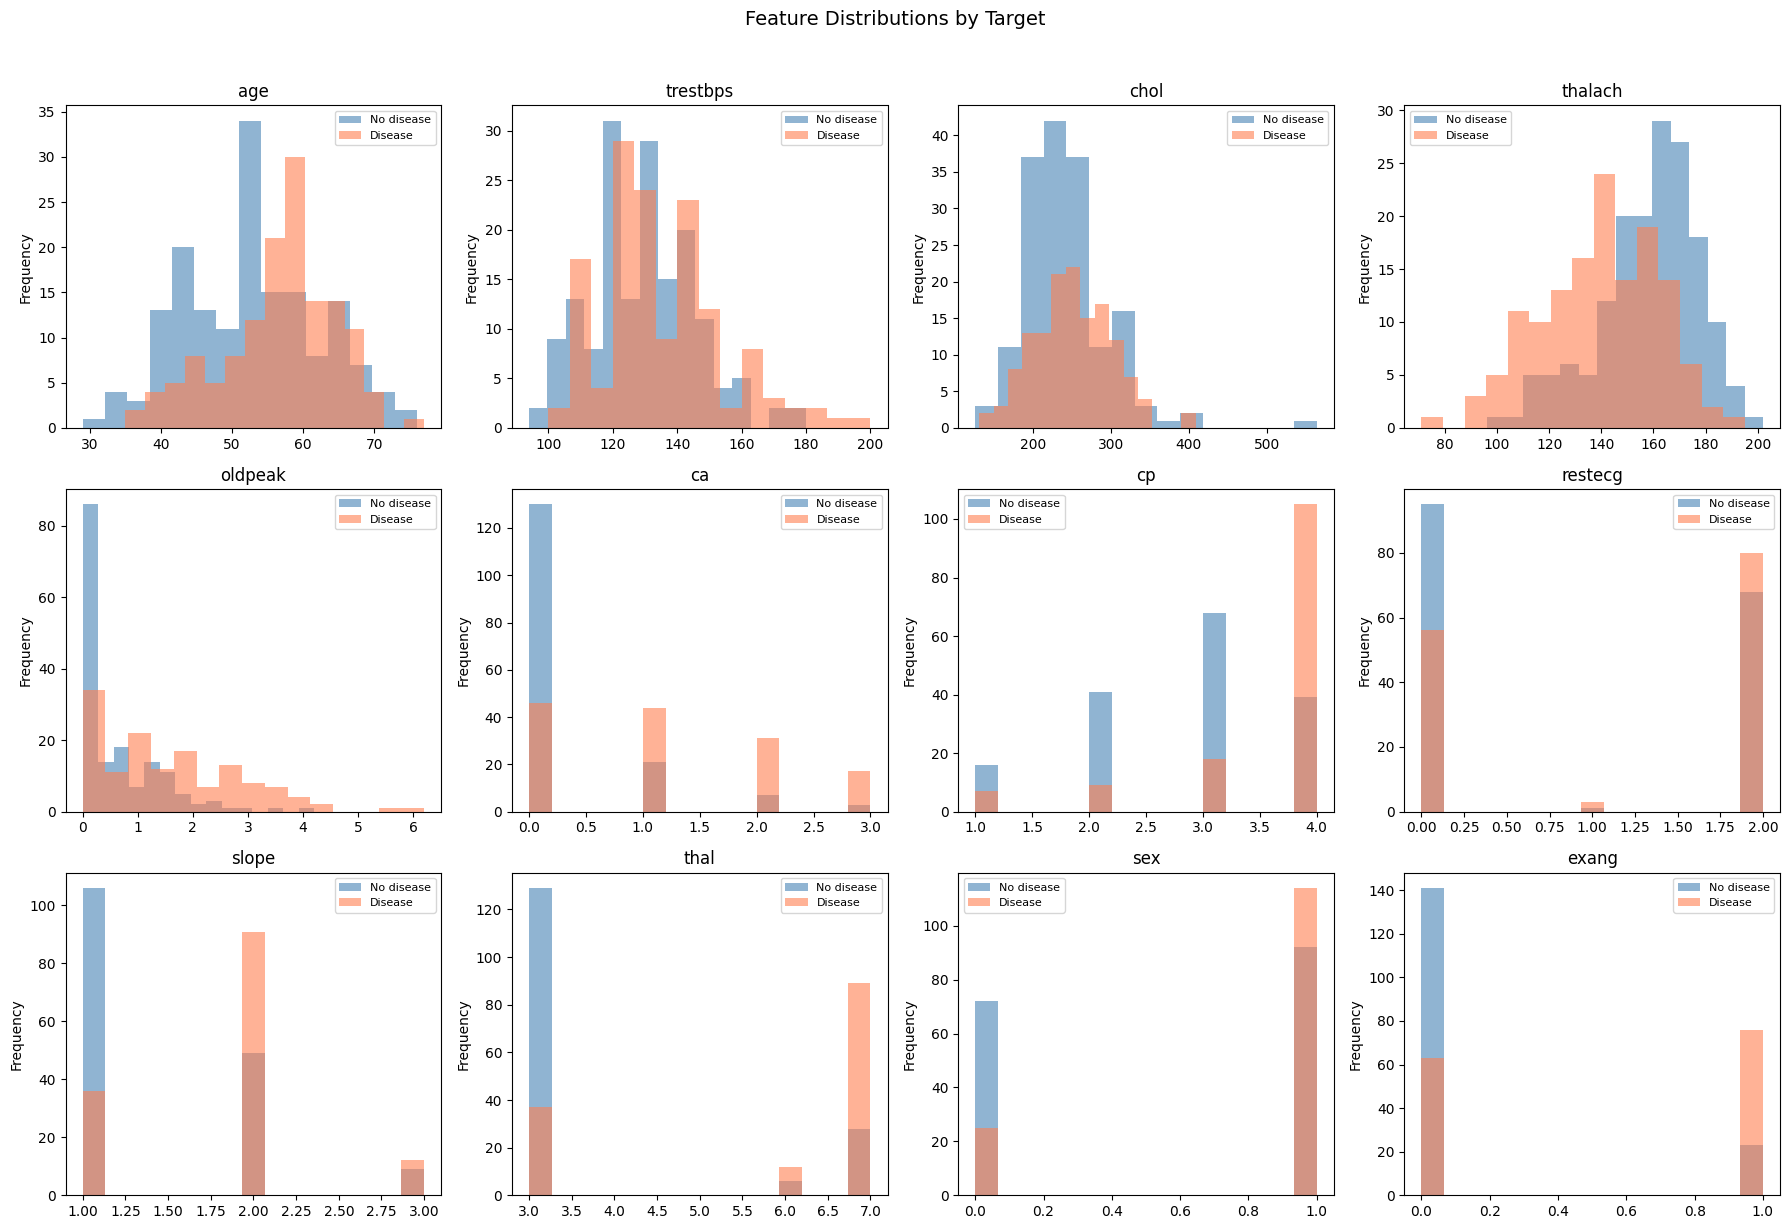

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
            'ca', 'cp', 'restecg', 'slope', 'thal', 'sex', 'exang']

for i, col in enumerate(features):
    df[df['target'] == 0][col].plot(kind='hist', ax=axes[i], alpha=0.6,
                                     label='No disease', color='steelblue', bins=15)
    df[df['target'] == 1][col].plot(kind='hist', ax=axes[i], alpha=0.6,
                                     label='Disease', color='coral', bins=15)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Correlation Heatmap

Pairwise linear correlations between all features and the target. Key finding: `thal`, `ca`, `exang`, `oldpeak` show strongest correlations — all direct cardiac diagnostic results, not basic vitals. `chol` correlation is near-zero (0.085) despite being a known CAD risk factor — likely due to selection bias: patients already undergoing angiography were mostly high-risk and on statins.

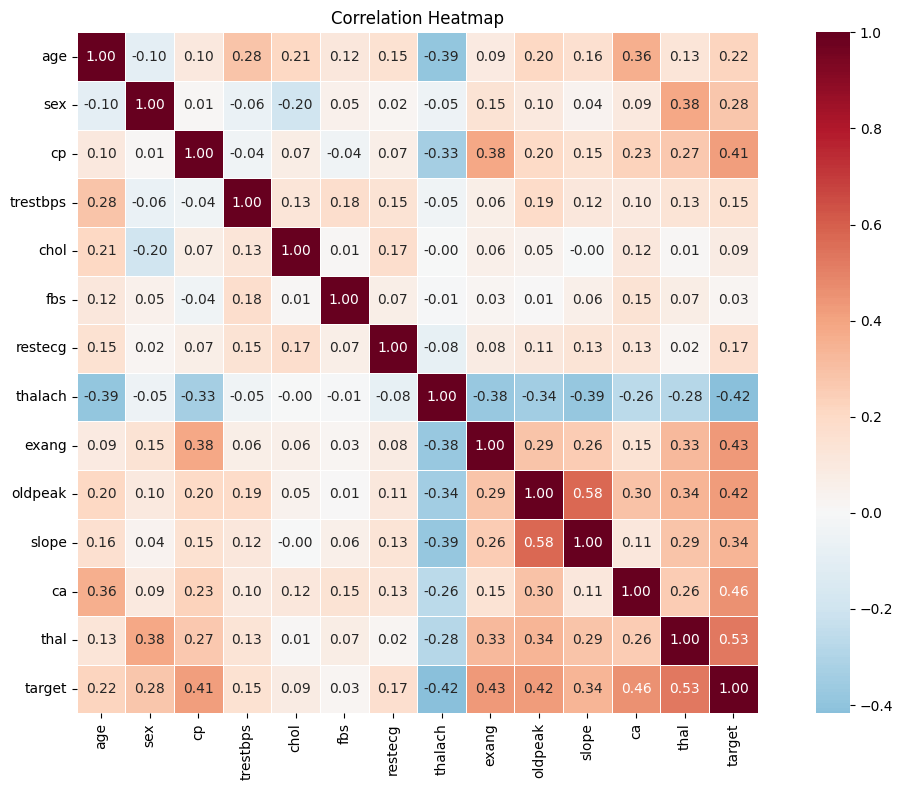


Correlation with target (ranked):
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
thalach    -0.417
Name: target, dtype: float64


In [9]:
plt.figure(figsize=(12, 8))
corr = df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (ranked):")
print(corr['target'].drop('target').sort_values(ascending=False).round(3))

### Categorical Feature Breakdown

Disease rate within each category. Notable finding: `cp=4` (asymptomatic) has the highest disease rate — many CAD patients have silent ischaemia. `thal=7` (reversible defect) has the highest disease rate in the thal column, consistent with active ischaemia under stress.

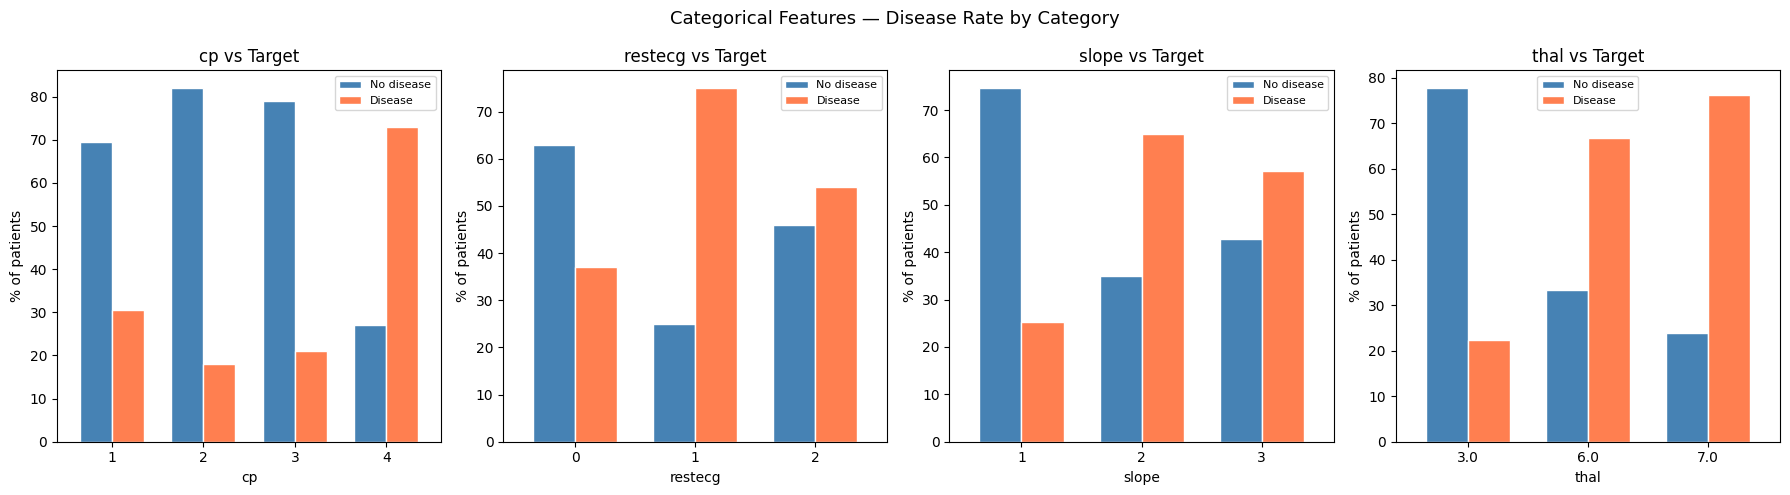

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% of patients')
    axes[i].legend(['No disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features — Disease Rate by Category', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Pipeline Construction

A Sklearn Pipeline chains preprocessing and modelling into one object. This prevents data leakage structurally — the preprocessor is only ever fit on training data, even inside `cross_val_score` and `GridSearchCV`.

**Structure:**
```
ColumnTransformer
├── numeric_pipeline   → SimpleImputer(median) → StandardScaler
├── binary_pipeline    → StandardScaler
└── categorical_pipeline → SimpleImputer(most_frequent) → OneHotEncoder
        ↓
    Classifier
```

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric pipeline — impute then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Binary pipeline — already 0/1, just scale
binary_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical pipeline — impute then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all three into one ColumnTransformer
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols),
    ('binary', binary_pipeline, binary_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

print("Preprocessor built successfully")
print("\nNumeric cols:", numeric_cols)
print("Binary cols:", binary_cols)
print("Categorical cols:", categorical_cols)

Preprocessor built successfully

Numeric cols: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Binary cols: ['sex', 'fbs', 'exang']
Categorical cols: ['cp', 'restecg', 'slope', 'thal']


### Sanity Check — Feature Expansion

One-hot encoding expands categorical columns: 13 original features → 22 after encoding (`cp`, `restecg`, `slope`, `thal` each expand into binary dummy columns).

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Sanity check — shape after preprocessing
X_transformed = preprocessor.fit_transform(X_train)
print(f"Shape after preprocessing: {X_transformed.shape}")
print("Original features: 13  →  After encoding:", X_transformed.shape[1])

Shape after preprocessing: (242, 22)
Original features: 13  →  After encoding: 22


## 5. Model Comparison

Four models evaluated inside the Pipeline. `class_weight='balanced'` applied to Random Forest — will validate whether it helps on this near-balanced dataset (54/46 split).

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42,
                                         class_weight='balanced'))
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', SVC(kernel='rbf', probability=True, random_state=42))
    ])
}

print("Pipelines built:", list(pipelines.keys()))

Pipelines built: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']


In [14]:
from sklearn.metrics import classification_report, roc_auc_score

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': round(report['accuracy'], 2),
        'Precision (disease)': round(report['1']['precision'], 2),
        'Recall (disease)': round(report['1']['recall'], 2),
        'F1 (disease)': round(report['1']['f1-score'], 2),
        'AUC': round(auc, 2)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision (disease)  Recall (disease)  F1 (disease)  AUC
Logistic Regression      0.87                 0.81              0.93          0.87 0.96
      Decision Tree      0.77                 0.71              0.86          0.77 0.80
      Random Forest      0.92                 0.87              0.96          0.92 0.95
                SVM      0.92                 0.87              0.96          0.92 0.96


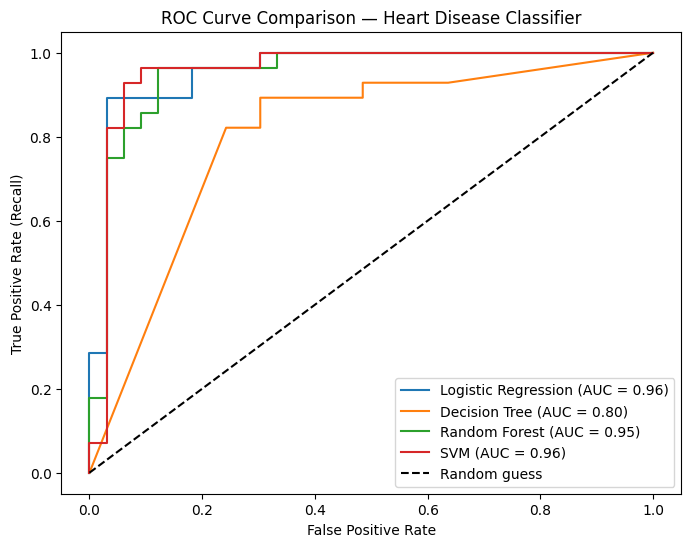

In [15]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, pipeline in pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison — Heart Disease Classifier')
plt.legend()
plt.show()

## 6. Cross-Validation

5-fold stratified cross-validation gives a more reliable performance estimate than a single train/test split. The single test split AUCs (0.95–0.96) were optimistic — CV provides the honest estimate.

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross Validation AUC Scores:")
print("-" * 50)

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    print(f"{name:<25} {scores.mean():.2f} ± {scores.std():.2f}")

5-Fold Cross Validation AUC Scores:
--------------------------------------------------
Logistic Regression       0.91 ± 0.02
Decision Tree             0.78 ± 0.06
Random Forest             0.91 ± 0.03
SVM                       0.90 ± 0.03


## 7. Hyperparameter Tuning

GridSearchCV on the full Random Forest Pipeline. Note the `model__` prefix syntax — required when referencing parameters inside a Pipeline step.

`class_weight` included as a parameter to tune — allows GridSearch to confirm whether balancing helps on this dataset.

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__class_weight': ['balanced', None]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters:", grid_search_rf.best_params_)
print("Best CV AUC:", round(grid_search_rf.best_score_, 3))

best_rf = grid_search_rf.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:, 1]
print("Test AUC with best RF:", round(roc_auc_score(y_test, y_proba_best), 3))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV AUC: 0.899
Test AUC with best RF: 0.952


## 8. SHAP Analysis

SHAP (SHapley Additive exPlanations) explains why the model made each prediction.

- **Global SHAP (bar plot):** Which features matter most on average across all patients
- **Directional SHAP (dot plot):** Which direction each feature pushes predictions — red = high feature value, blue = low. Dots pushed right = increases disease prediction

This is what clinicians need before acting on a model's output — not just which features matter, but how and for whom.

In [18]:
!pip install shap -q
import shap

rf_pipeline = pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['model']
X_test_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

# Handle SHAP version differences
# Old SHAP: returns list [class_0_array, class_1_array]
# New SHAP: returns single array with shape (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_vals_disease = shap_values[1]
else:
    shap_vals_disease = shap_values[:, :, 1]

print("SHAP values computed successfully")
print("shap_vals_disease shape:", shap_vals_disease.shape)
print("X_test_transformed shape:", X_test_transformed.shape)

SHAP values computed successfully
shap_vals_disease shape: (61, 22)
X_test_transformed shape: (61, 22)


In [19]:
# Get feature names after one-hot encoding
numeric_feature_names = numeric_cols + binary_cols

categorical_feature_names = rf_pipeline.named_steps['preprocessor']\
    .named_transformers_['categorical']\
    .named_steps['encoder']\
    .get_feature_names_out(categorical_cols).tolist()

all_feature_names = numeric_feature_names + categorical_feature_names

print(f"Total feature names: {len(all_feature_names)}")
print(all_feature_names)

Total feature names: 22
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs', 'exang', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']


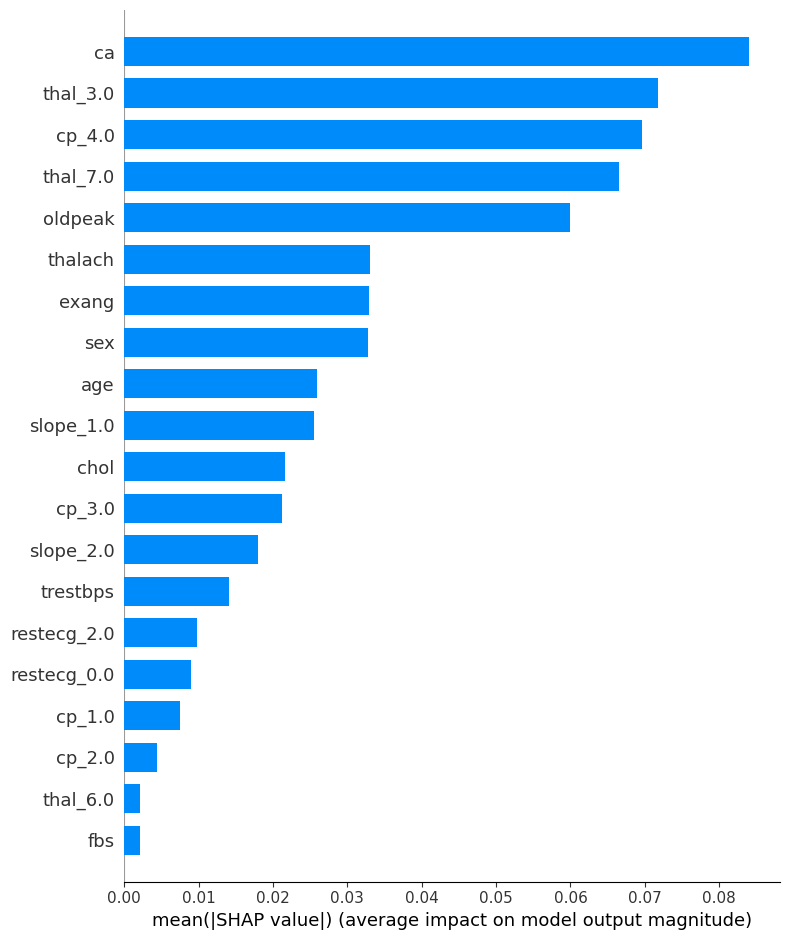

In [20]:
# Global SHAP — feature importance bar plot
shap.summary_plot(shap_vals_disease,
                  X_test_transformed,
                  feature_names=all_feature_names,
                  plot_type='bar')

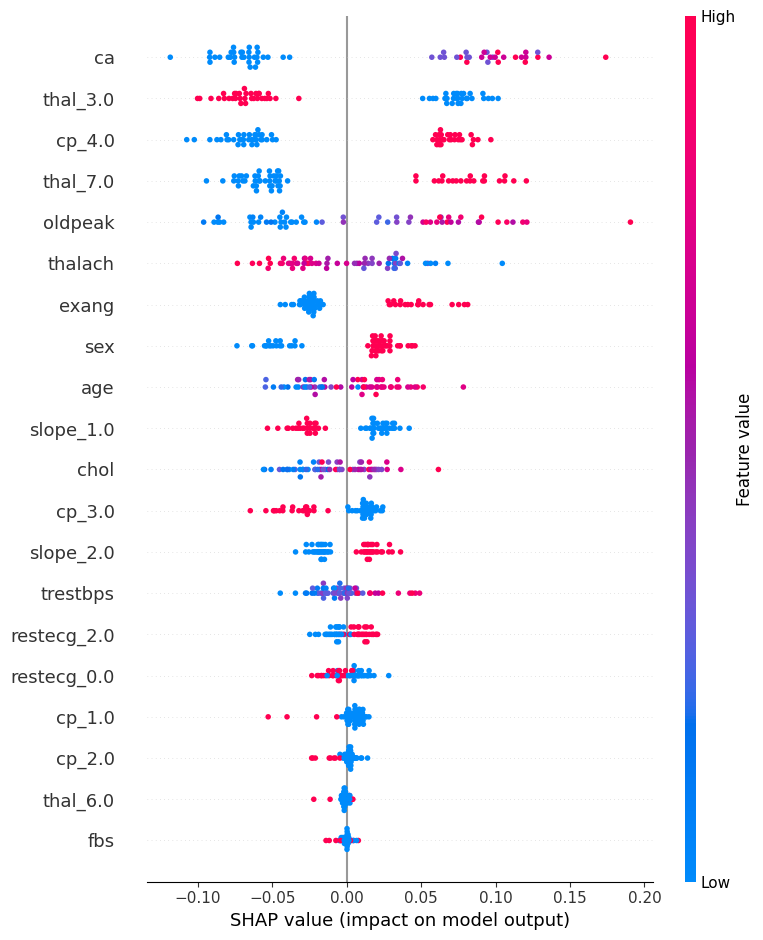

In [21]:
# Directional SHAP — dot plot
# Red = high feature value, Blue = low feature value
# Dots right of centre = pushes prediction toward disease
shap.summary_plot(shap_vals_disease,
                  X_test_transformed,
                  feature_names=all_feature_names)

## 9. Threshold Tuning

Default threshold of 0.5 already achieves 0.96 recall — stronger baseline than Project 1 due to higher quality features. Threshold lowered to 0.3 to achieve perfect recall (0 missed disease patients), at the cost of precision dropping from 0.84 to 0.72. Clinically acceptable for a screening tool where false negatives carry higher risk than false positives.

In [22]:
from sklearn.metrics import confusion_matrix

rf_pipeline = pipelines['Random Forest']
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<10} {'False Negatives'}")
print("-" * 58)

for threshold in [0.5, 0.4, 0.3]:
    y_pred_custom = (y_proba_rf >= threshold).astype(int)

    tp = ((y_pred_custom == 1) & (y_test == 1)).sum()
    fn = ((y_pred_custom == 0) & (y_test == 1)).sum()
    fp = ((y_pred_custom == 1) & (y_test == 0)).sum()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"{threshold:<12} {recall:.2f}{'':6} {precision:.2f}{'':8} {f1:.2f}{'':6} {fn}")

Threshold    Recall     Precision    F1         False Negatives
----------------------------------------------------------
0.5          0.96       0.84         0.90       1
0.4          0.96       0.77         0.86       1
0.3          1.00       0.72         0.84       0


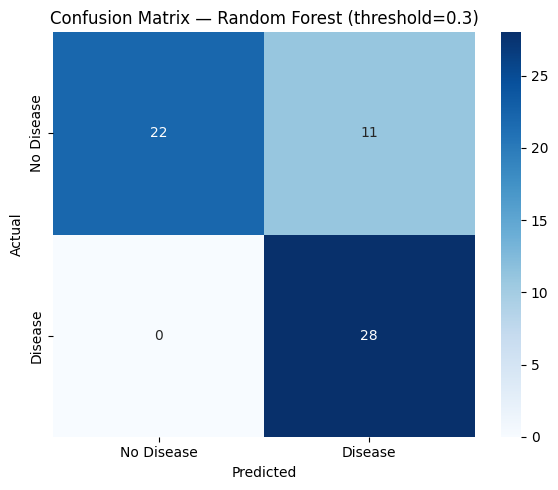

              precision    recall  f1-score   support

  No Disease       1.00      0.67      0.80        33
     Disease       0.72      1.00      0.84        28

    accuracy                           0.82        61
   macro avg       0.86      0.83      0.82        61
weighted avg       0.87      0.82      0.82        61



In [23]:
THRESHOLD = 0.3
y_pred_final = (y_proba_rf >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — Random Forest (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final,
                             target_names=['No Disease', 'Disease']))

## 10. Save Model

In [24]:
import joblib

# Save full pipeline — preprocessor + model in one object
# No separate scaler file needed (Pipeline handles everything internally)
joblib.dump(rf_pipeline, 'heart_disease_model.pkl')

print("Model saved: heart_disease_model.pkl")

# Verify
loaded_pipeline = joblib.load('heart_disease_model.pkl')
test_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
print(f"Verification AUC: {roc_auc_score(y_test, test_proba):.3f}")

Model saved: heart_disease_model.pkl
Verification AUC: 0.950


---

## Summary

| Metric | Value |
|---|---|
| Dataset | UCI Cleveland — 303 patients, 13 features |
| Class balance | 54% no disease / 46% disease |
| Best model | Random Forest (Pipeline) |
| CV AUC | 0.91 ± 0.03 |
| Test AUC | 0.95 |
| Selected threshold | 0.3 |
| False negatives at threshold 0.3 | 0 (28/28 disease patients correctly flagged) |
| Top SHAP predictors | ca, thal_3.0, cp_4.0, thal_7.0, oldpeak |

**Clinical reasoning:** Threshold lowered from 0.5 to 0.3 to achieve perfect recall — missing a heart disease patient has serious clinical consequences. At threshold 0.3, precision drops to 0.72 (11 false alarms out of 33 flagged), which is an acceptable tradeoff for a screening tool. SHAP analysis confirms model decisions are driven by direct cardiac diagnostic markers (ca, thal, oldpeak) — consistent with established cardiology evidence.

**Dataset limitation:** Top features are stress test and catheterisation results, not basic vitals. This model performs well on patients already undergoing cardiac workup — it would not generalise to primary care screening where these tests haven't been performed yet.

